# Photometry of M16 (The Eagle Nebula)
## Section 1: Importing Modules and Libraries

In [1]:
#import packages 
#special zoom features on images
%matplotlib widget  
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time
import astropy.units as u
import urllib.request
import os
import shutil
from astropy.io import fits
from astropy.utils.data import download_file
from astropy.visualization import astropy_mpl_style
from astropy.stats import sigma_clipped_stats 
import photutils
from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture
from photutils.profiles import RadialProfile
from astropy.visualization import ZScaleInterval, AsinhStretch, ImageNormalize
from astropy.nddata.utils import Cutout2D
from scipy.optimize import curve_fit


## Section 2: Downloading the FITS Image of M16
### Here, we use a URI from the MAST HST archive and an astropy package to download the FITS file. 

In [2]:
m16_url = "https://mast.stsci.edu/api/v0.1/Download/file/?uri=mast:HST/product/idnm29ytq_drz.fits" #URL of M16 image from the MAST Archive 
m16_file = download_file(m16_url, cache = True)
m16_file 
#"https://opencomputinglab.github.io/SubjectMatterNotebooks/astronomy/fits-images.html"

'C:\\Users\\mya\\.astropy\\cache\\download\\url\\f8cf98df576c56953cbeb544353cc99a\\contents'

In [3]:
m16_hdu_list = fits.open(m16_file) 
if 'm16.fits' not in os.listdir():
    m16_hdu_list.writeto('m16.fits')
    print("File successfully downloaded!")
else:
    print("File is already downloaded.")

m16_data = fits.getdata('m16.fits')

File is already downloaded.


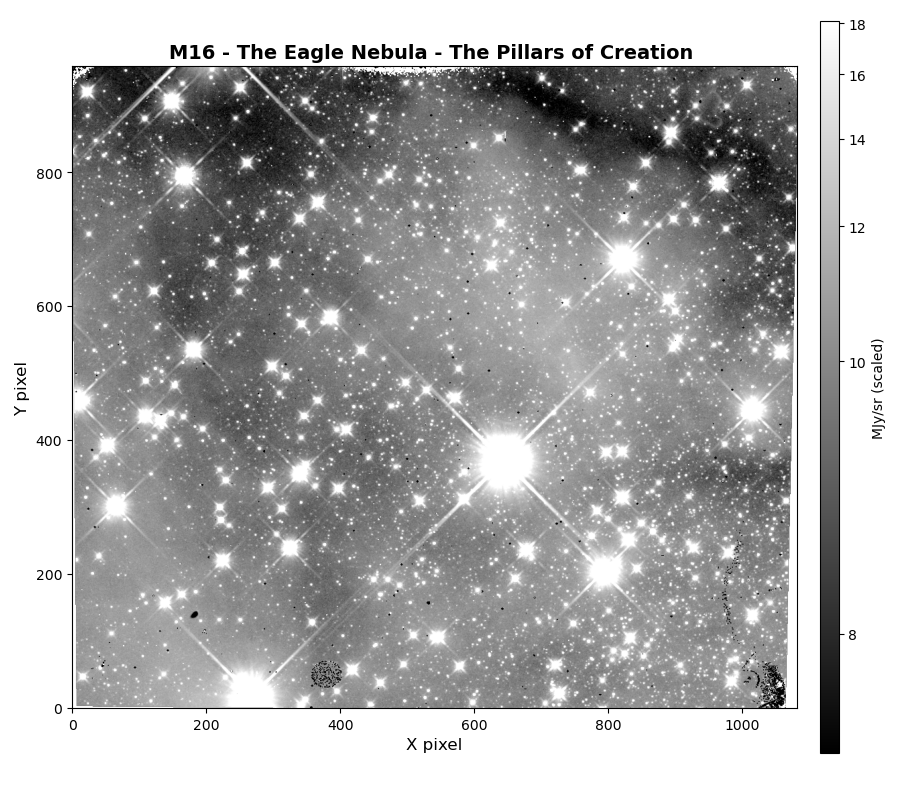

In [4]:
if os.path.exists(m16_file) and m16_data is not None:
    
    # Combine interval (ZScale finds optimal min/max) with stretch (AsinhStretch compresses dynamic range)
    norm = ImageNormalize(m16_data, 
                          interval=ZScaleInterval(),
                          stretch=AsinhStretch())
    
    # Calculate figure size maintaining aspect ratio
    aspect_ratio = m16_data.shape[0] / m16_data.shape[1]
    fig_width = 9
    fig_height = fig_width * aspect_ratio
    
    plt.figure(figsize=(fig_width, fig_height))
    
    # origin='lower' puts (0,0) at bottom-left (astronomical convention)
    plt.imshow(m16_data, cmap='gray', origin='lower', norm=norm)
    plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
    plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
              fontsize=14, fontweight='bold')
    plt.xlabel('X pixel', fontsize=12)
    plt.ylabel('Y pixel', fontsize=12)
    plt.tight_layout()
    plt.show()
elif os.path.exists(m16_file):
    print("Skipping visualization - no image data loaded")

9.960842 9.955563 1.1637075


id,x_centroid,y_centroid,sharpness,roundness1,roundness2,n_pixels,peak,flux,mag,daofind_mag
int64,float64,float64,float64,float32,float64,int64,float32,float32,float32,float64
1,643.7391006747155,368.2685504324055,0.35610570541306774,0.069916174,-0.12737961186739608,25,39936.85,685535.9,-14.590075,-8.746401015765478
2,267.9713283886196,17.58503719254132,0.4355398532238545,0.23845488,0.2726421307211509,25,43425.26,588881.7,-14.42507,-9.200612391557337
3,791.3415328060985,202.04279227949456,0.35036860446957246,-0.17016268,-0.0925930820623757,25,40200.176,379156.75,-13.947047,-9.506651359192041
4,820.4151048443399,668.5889452719462,0.38453540914987305,-0.41329256,-0.10058177079806203,25,36826.996,377480.5,-13.942236,-9.301332336972722
5,1013.7072451688485,443.02196240569515,0.5042008722157687,-0.054211218,-0.16490869546787687,25,37766.242,268266.62,-13.571416,-9.41149131963603
6,6.737797562616275,458.63544548266367,0.5554236198457435,-0.2542175,0.10738784073543159,25,34938.93,232552.36,-13.416302,-9.30364572484417
7,65.23376750696886,300.55585965664204,0.5083895192755504,-0.33292526,-0.003357662237018754,25,34945.03,222848.11,-13.370023,-9.376011740155912
8,167.39788741409376,792.8931609692703,0.5403066357703773,-0.21277478,-0.2994293320670047,25,27924.668,195163.73,-13.225998,-9.052056059826016
9,181.3321270598217,533.6256775669736,0.5538802871717877,-0.19796002,-0.10771524107539221,25,25682.902,143390.7,-12.891302,-9.04316045212926


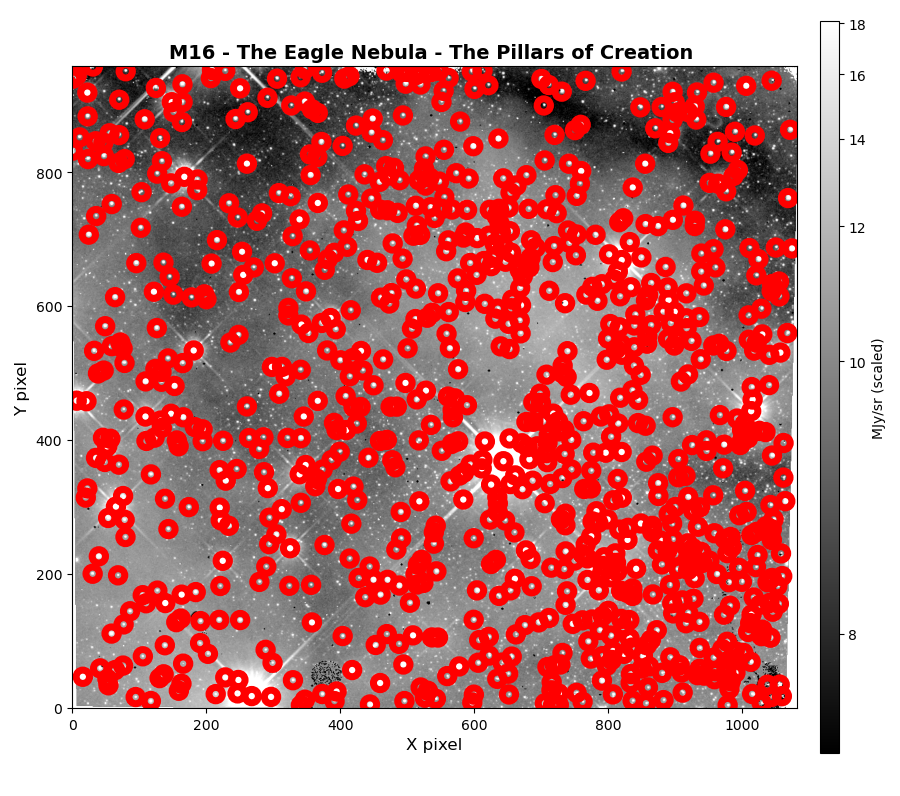

In [5]:

mean, median, std = sigma_clipped_stats(m16_data, sigma=3.0) 
print(mean, median, std)

daofind = DAOStarFinder(fwhm=3.0, threshold=5*std, n_brightest=900) #locating stars from FITS data
# searches images for local density maxima that have a peak amplitude greater than threshold (approximately; threshold is applied to a convolved image) and have a size and shape similar to the defined 2D Gaussian kernel (eveything is already fit)
# find sources and display in a table

sources = daofind(m16_data-median)
display(sources)
#bright_sources = sources[sources['flux'] > 5000]

#display(bright_sources)

 # code from DESI ASTRO, image display with circular apertures around each star from the x & y position data
positions = np.transpose((sources['x_centroid'],sources['y_centroid']))
plt.figure(figsize=(fig_width, fig_height)) 
apertures = CircularAperture(positions,r=10) 
apertures.plot(color='red',lw=5)

plt.imshow(m16_data, cmap='gray', origin='lower', norm=norm)
plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
            fontsize=14, fontweight='bold')
plt.xlabel('X pixel', fontsize=12)
plt.ylabel('Y pixel', fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
stars = sources['id', 'x_centroid', 'y_centroid', 'n_pixels', 'mag', 'peak'] # display necessary data
display(stars)

id,x_centroid,y_centroid,n_pixels,mag,peak
int64,float64,float64,int64,float32,float32
1,643.7391006747155,368.2685504324055,25,-14.590075,39936.85
2,267.9713283886196,17.58503719254132,25,-14.42507,43425.26
3,791.3415328060985,202.04279227949456,25,-13.947047,40200.176
4,820.4151048443399,668.5889452719462,25,-13.942236,36826.996
5,1013.7072451688485,443.02196240569515,25,-13.571416,37766.242
6,6.737797562616275,458.63544548266367,25,-13.416302,34938.93
7,65.23376750696886,300.55585965664204,25,-13.370023,34945.03
8,167.39788741409376,792.8931609692703,25,-13.225998,27924.668
9,181.3321270598217,533.6256775669736,25,-12.891302,25682.902


## Section 3: Photometry Class Implementation
### In this section, we create a class that has the capability to check the download status of the FITS file, display the image, and display the PSF model and radial profile of each star in the image.

### class

In [ ]:

class ClusterAnalyzer:
    """
    A class to perform PSF photometry on an astronomical image 
    of an open cluster.
    """
    
    def __init__(self, filename, fitsname, hdulist):
        """Initialize the object by loading the data."""
        self.filename = filename # name of the file that stores the fits data 
        self.fitsname = fitsname # fits data
        self.hdu_list = fits.open(self.filename) # fits header data 
        if 'self.fitsname' not in os.listdir():
            self.hdu_list.writeto('self.fitsname')
  
        
    
        
    def show_image(self, fitsname, filename, title="Open Cluster Field"):
        """Utility method to visualize the data."""
        self.filename = filename
        self.fitsname = fitsname
        if os.path.exists(filename) and fitsname is not None:
            from astropy.visualization import ZScaleInterval, AsinhStretch, ImageNormalize
    
    # Combine interval (ZScale finds optimal min/max) with stretch (AsinhStretch compresses dynamic range)
            norm = ImageNormalize(fitsname, 
                          interval=ZScaleInterval(),
                          stretch=AsinhStretch())
    
    # Calculate figure size maintaining aspect ratio
            aspect_ratio = fitsname.shape[0] / fitsname.shape[1]
            fig_width = 5
            fig_height = fig_width * aspect_ratio
    
            plt.figure(figsize=(fig_width, fig_height))
    
    # origin='lower' puts (0,0) at bottom-left (astronomical convention)
            plt.imshow(self.fitsname, cmap='gray', origin='lower', norm=norm)
            plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
            plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
              fontsize=14, fontweight='bold')
            plt.xlabel('X pixel', fontsize=12)
            plt.ylabel('Y pixel', fontsize=12)
            plt.tight_layout()
            plt.show()
        
        elif os.path.exists(filename):
            print("Skipping visualization - no image data loaded")
    
    def detect_star(self, fitsname):
        self.fitsname = fitsname 
        mean, median, std = sigma_clipped_stats(self.fitsname, sigma=3.0) #ignore outliers and NaNs from file 
        print(mean, median, std)

        daofind = DAOStarFinder(fwhm=3.0,threshold=5*std, n_brightest=900) #locating stars from fits data, searches images for local density maxima that have a peak amplitude greater than threshold (approximately; threshold is applied to a convolved image) and have a size and shape similar to the defined 2D Gaussian kernel (eveything is already fit)
        # find sources
        sources = daofind(self.fitsname-median)
        display(sources)

        from photutils.aperture import CircularAperture #code from DESI ASTRO 
        positions = np.transpose((sources['x_centroid'], sources['y_centroid']))
        plt.figure(figsize=(fig_width, fig_height))
        apertures=CircularAperture(positions,r=10) #apertures around each star in cluster 
        apertures.plot(color='red',lw=2)

        plt.imshow(self.fitsname, cmap='gray', origin='lower', norm=norm)
        plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
        plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
            fontsize=14, fontweight='bold')
        plt.xlabel('X pixel', fontsize=12)
        plt.ylabel('Y pixel', fontsize=12)
        plt.tight_layout()
        plt.show()

            
    def fit_star_psf(self, fitsname, x_pos, y_pos, size, peak):
        
        self.fitsname = fitsname
        self.x_pos = x_pos # star x position
        self.y_pos = y_pos # star y position
        self.size = size
        self.peak = peak

        plt.figure(figsize=(fig_width, fig_height))
        sigma = 3.0 
        fwhm = 2.355 * sigma #width of gaussian fit 
        cutout = Cutout2D(self.fitsname.data, (self.x_pos,self.y_pos), self.size) #cutout portion of image using fitted position values from the table above 
        minim = np.nanpercentile(cutout.data, 50) #
        maxim = np.nanpercentile(cutout.data, 99.9) #
        plt.imshow(cutout.data, origin='lower', cmap='gray', vmin=minim, vmax=maxim, norm='log') 
        plt.xlabel('X [15 pixels]')
        plt.ylabel('Y [15 pixels]')
        plt.title(f'Gaussian PSF for Star in M16 (FWHM = {fwhm:.1f} pixels)') 
                  #fontsize=12, fontweight='bold')
        # errors with plt.colorbar
        
        
#radial profile

        xycen = (self.x_pos, self.y_pos) #center of radial profile
        edge_radii = np.arange(25) # input radial bins edges (basically define boundaries for radius)
        rp = RadialProfile(m16_data, xycen, edge_radii) # Radial profile function uses mean flux in concentric circular annular bins and growth curves,
                                                        # finds cumulative flux within circular apertures 


       #plotting radial profile
        fig, ax = plt.subplots(figsize=(10, 10))
        rp.plot(ax=ax, color='C0')
        rp.plot_error(ax=ax)
        ax.plot(rp.data_radius, rp.data_profile, zorder=1, color='C1')
        rp.normalize(method='max')
       
        plt.xlabel('Radius [pixels]', fontsize=11)
        plt.ylabel('Intensity (linear scale)', fontsize=11)
        plt.title('Radial Profile for Star in M16', fontsize=12, fontweight='bold')
        plt.yscale('linear')
        plt.grid(True, alpha=0.3, which='both')
       
        rp.plot_error
        ax.legend
        plt.show()





### Here we use the class to extract coutouts from 10 star positions and plot the radial profile of each to assess the quality of the star's Gaussian fit to the 2D PSF model. 
#### The radial profile is plotted as intensity as a function of radius (in pixels).

## Radial Profiles

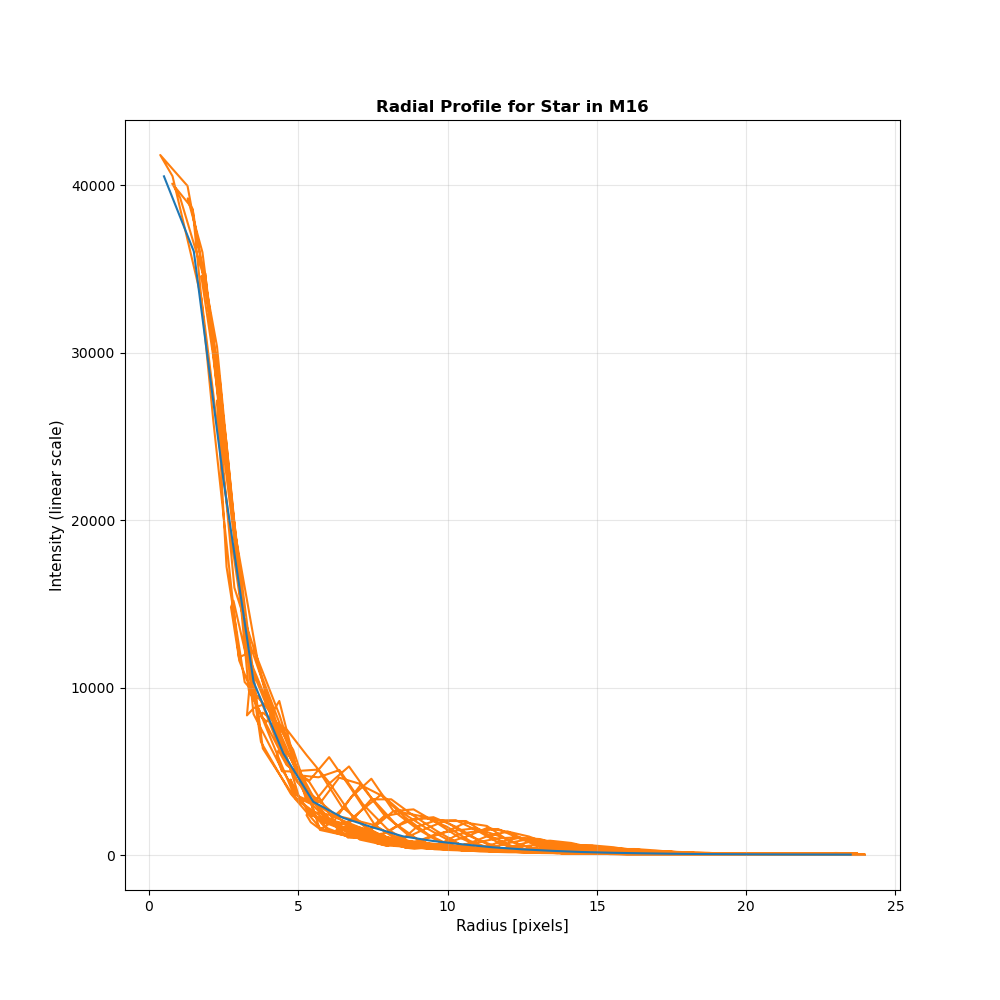

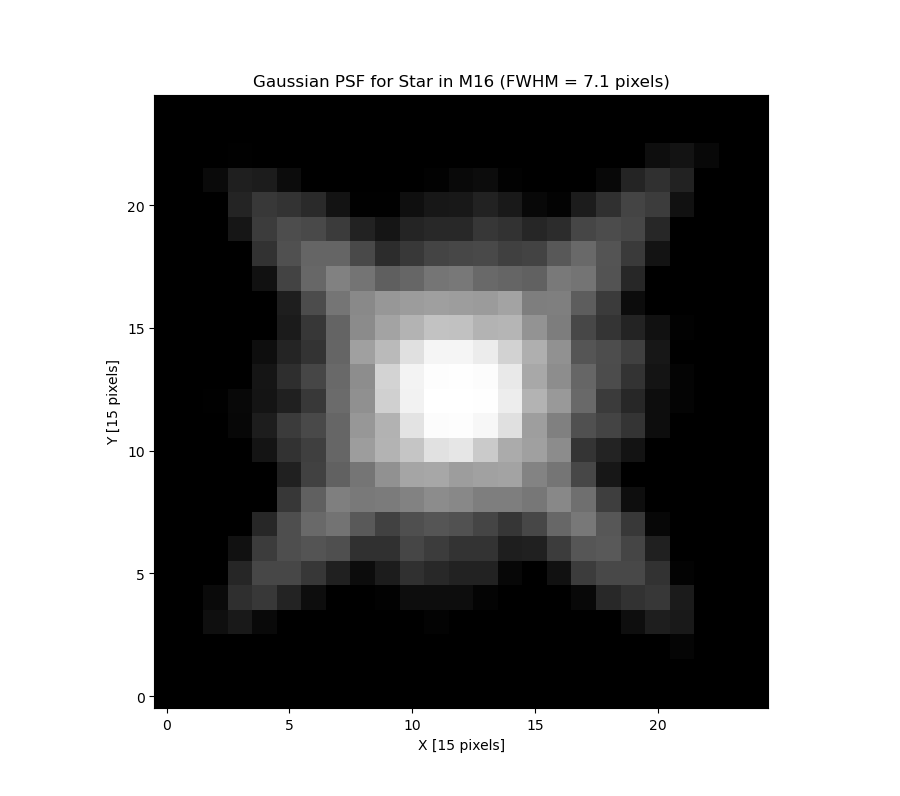

In [11]:
m16_cutout1 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
star1 = stars[0] 
x_pos, y_pos, size, peak = star1['x_centroid'], star1['y_centroid'], star1['n_pixels'], star1['peak']
m16_cutout1.fit_star_psf(m16_data, x_pos, y_pos, size, peak)

### Star 2

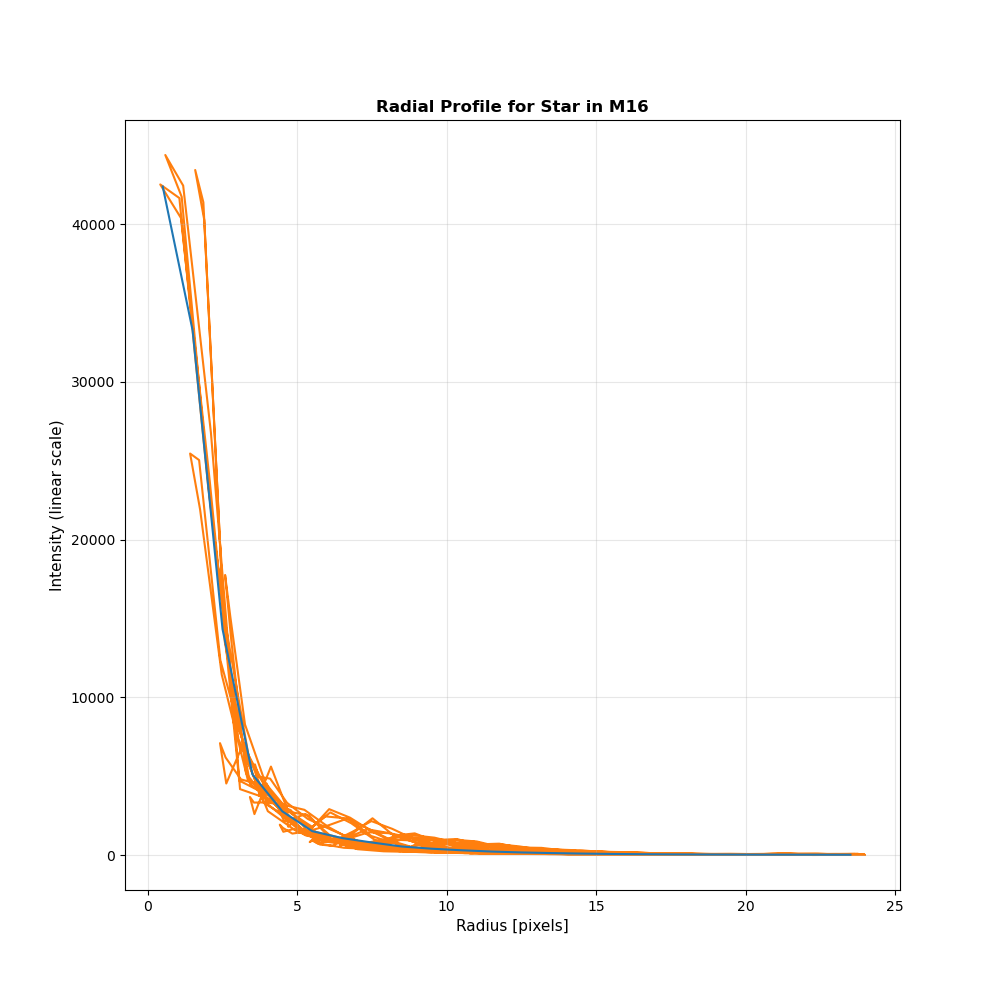

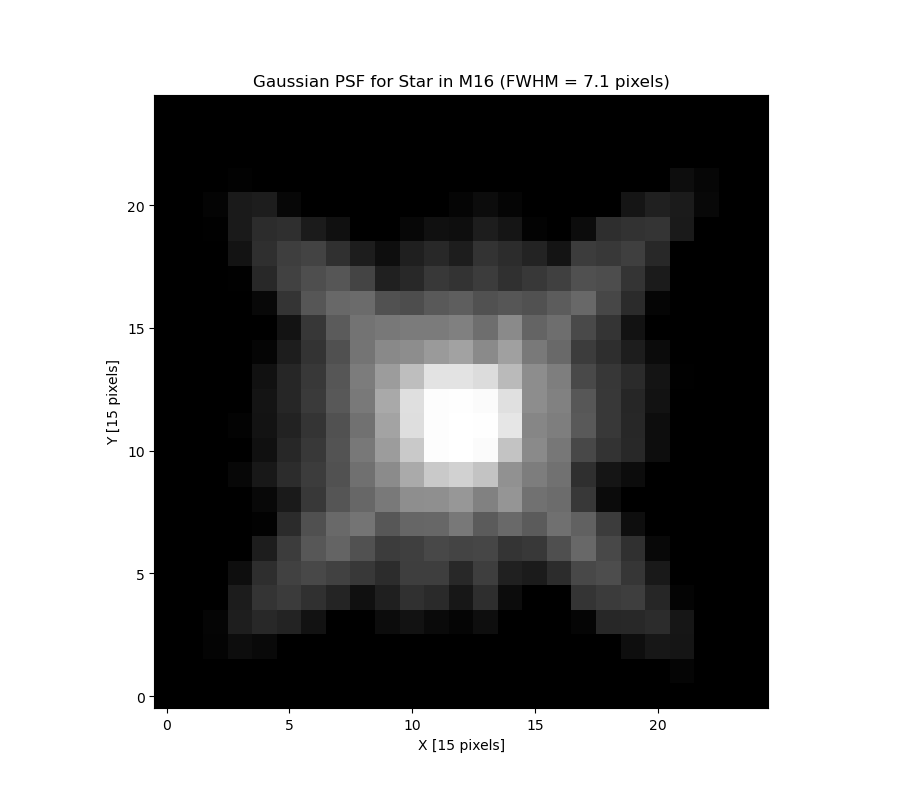

In [12]:
m16_cutout2 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
star2 = stars[1]
x_pos, y_pos, size, peak = star2['x_centroid'], star2['y_centroid'], star2['n_pixels'], star2['peak']
m16_cutout2.fit_star_psf(m16_data, x_pos, y_pos, size, peak)

### Star 3

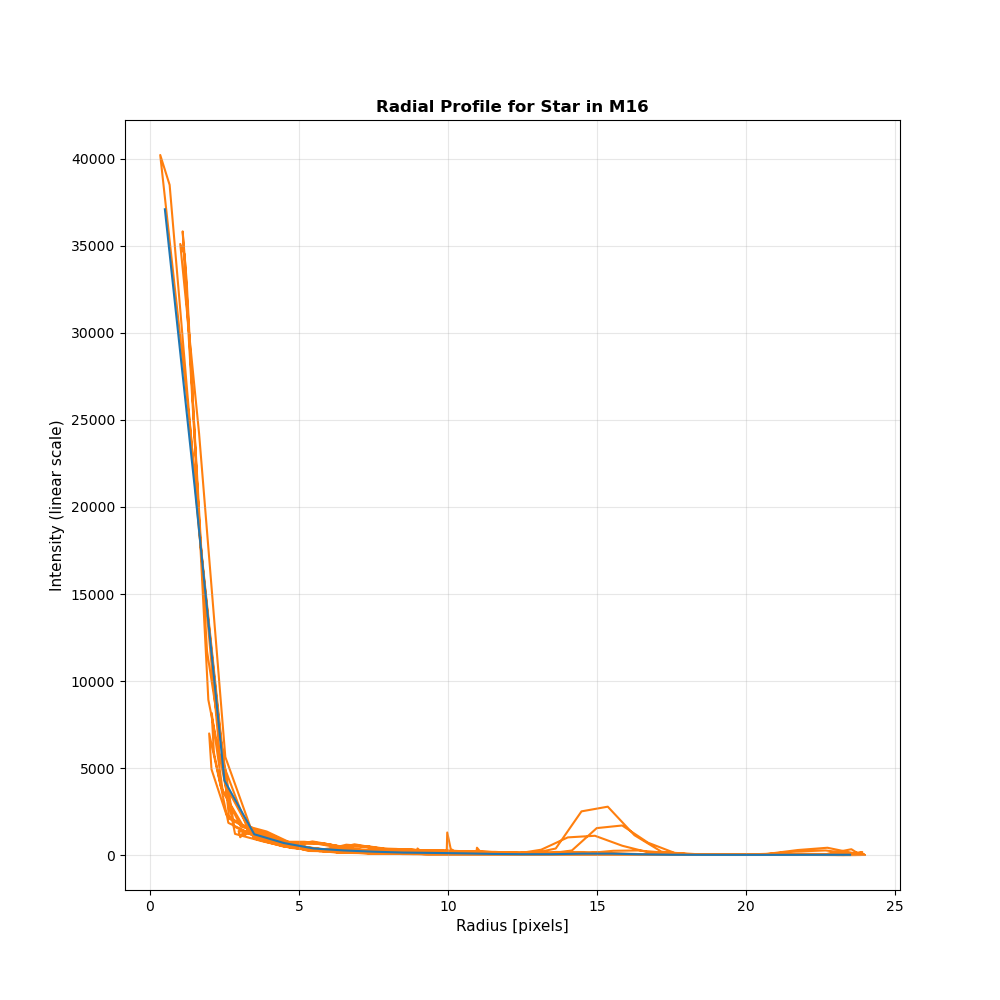

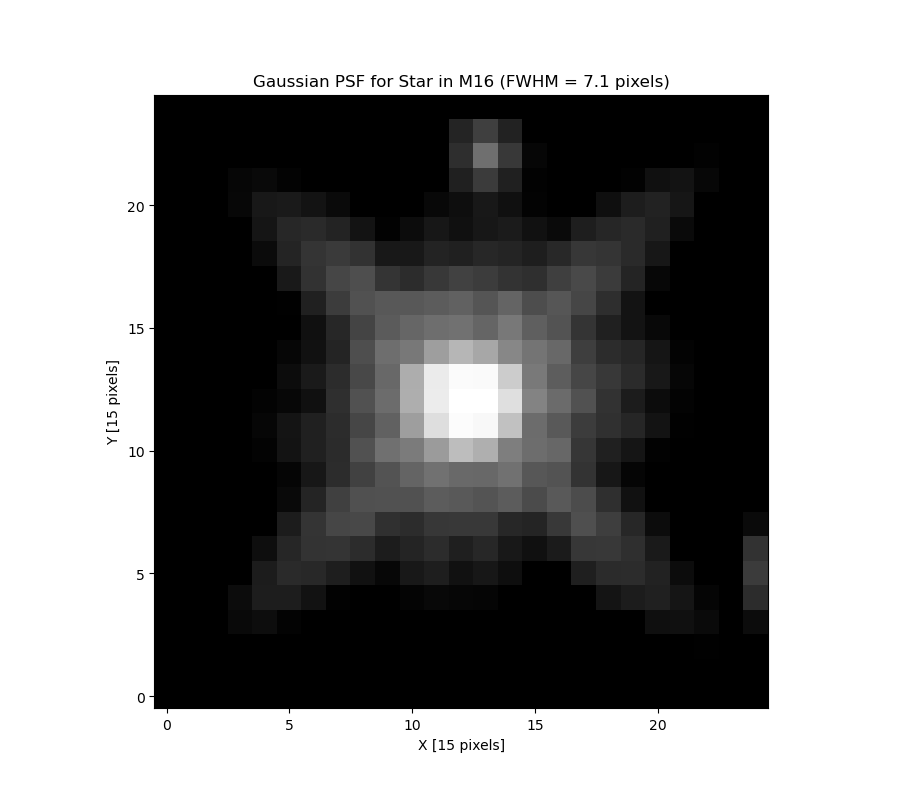

In [13]:
m16_cutout3 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
star3 = stars[2]
x_pos, y_pos, size, peak = star3['x_centroid'], star3['y_centroid'], star3['n_pixels'], star3['peak']
m16_cutout3.fit_star_psf(m16_data, x_pos, y_pos, size, peak)

### Star 4

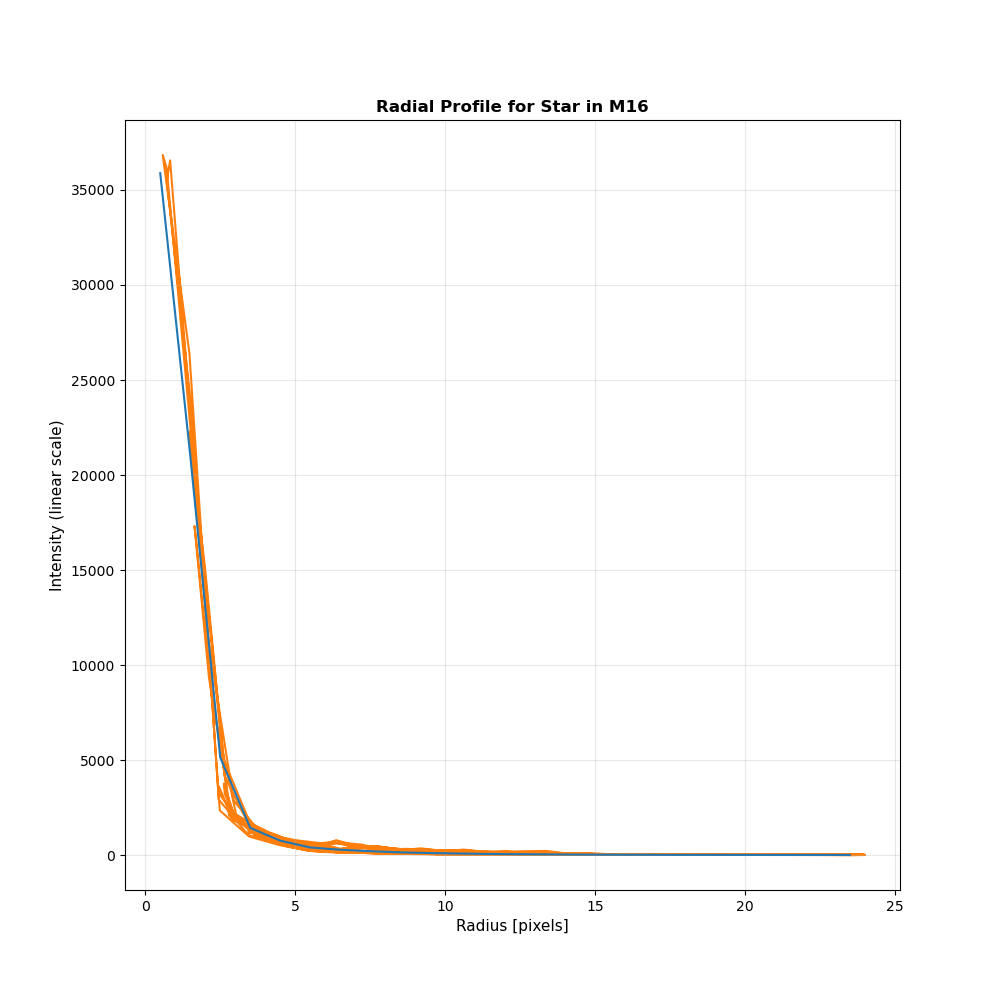

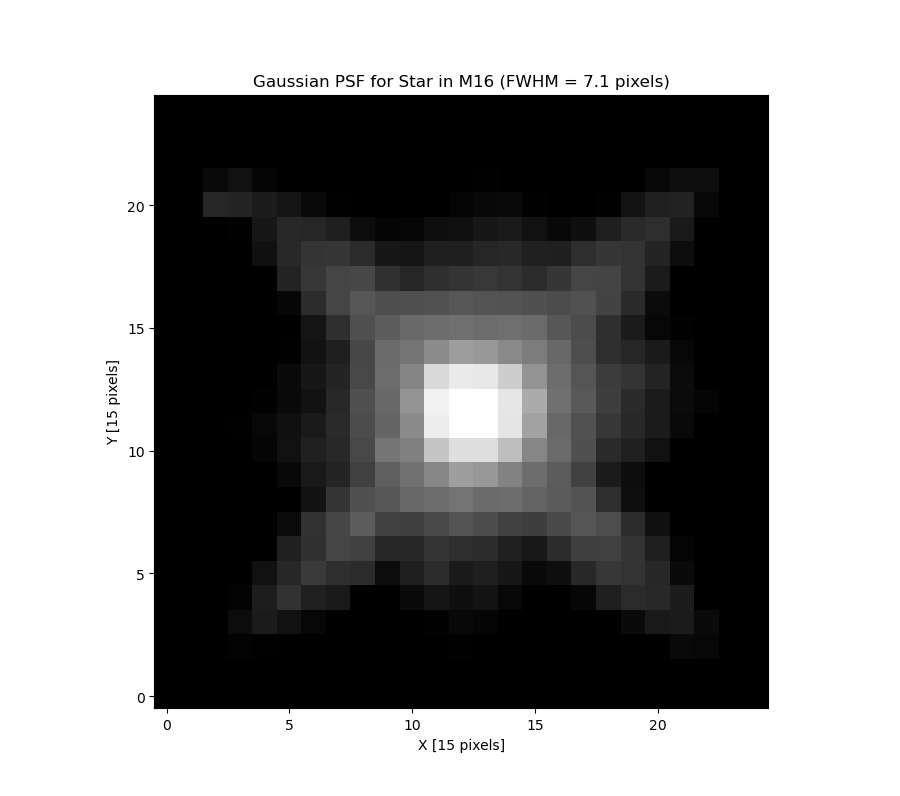

In [14]:
m16_cutout4 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
star4 = stars[3]
x_pos, y_pos, size, peak = star4['x_centroid'], star4['y_centroid'], star4['n_pixels'], star4['peak']
m16_cutout4.fit_star_psf(m16_data, x_pos, y_pos, size, peak)

### Star 5

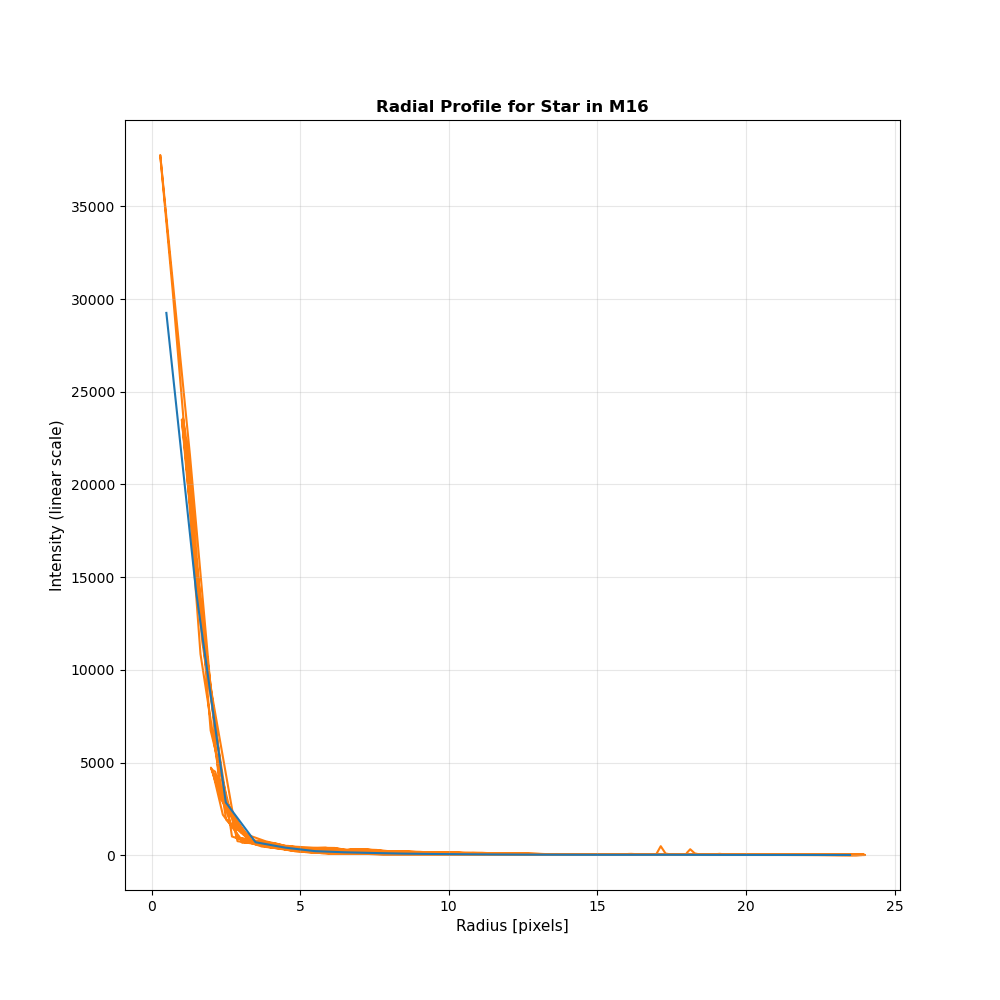

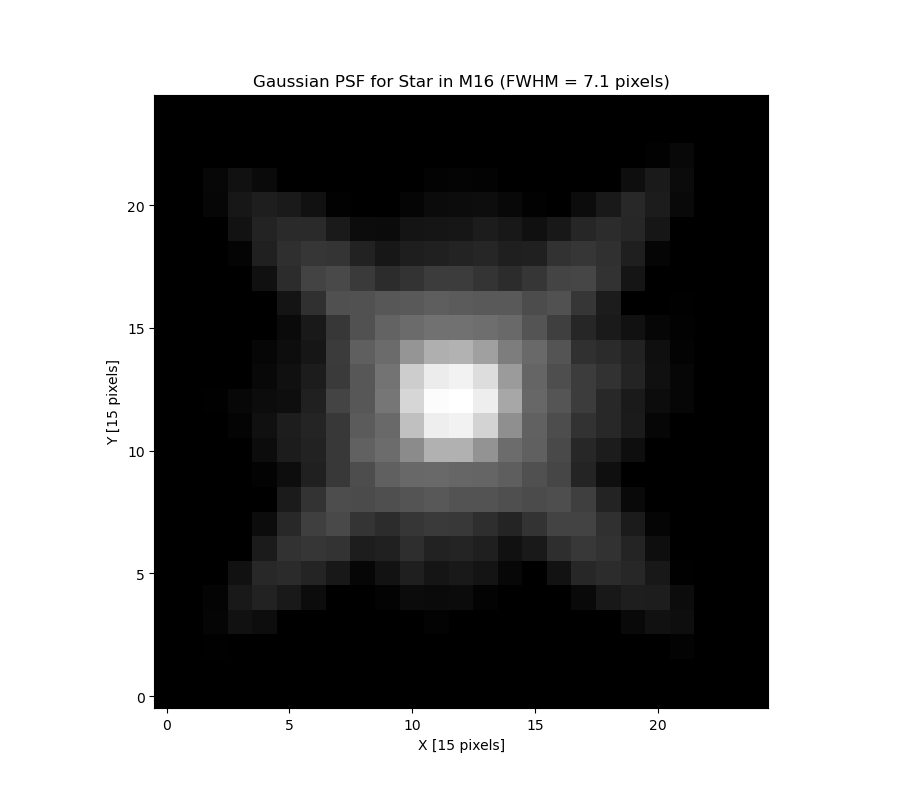

In [15]:
m16_cutout5= ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
star5 = stars[4]
x_pos, y_pos, size, peak = star5['x_centroid'], star5['y_centroid'], star5['n_pixels'], star5['peak']
m16_cutout5.fit_star_psf(m16_data, x_pos, y_pos, size, peak)

### Star 6

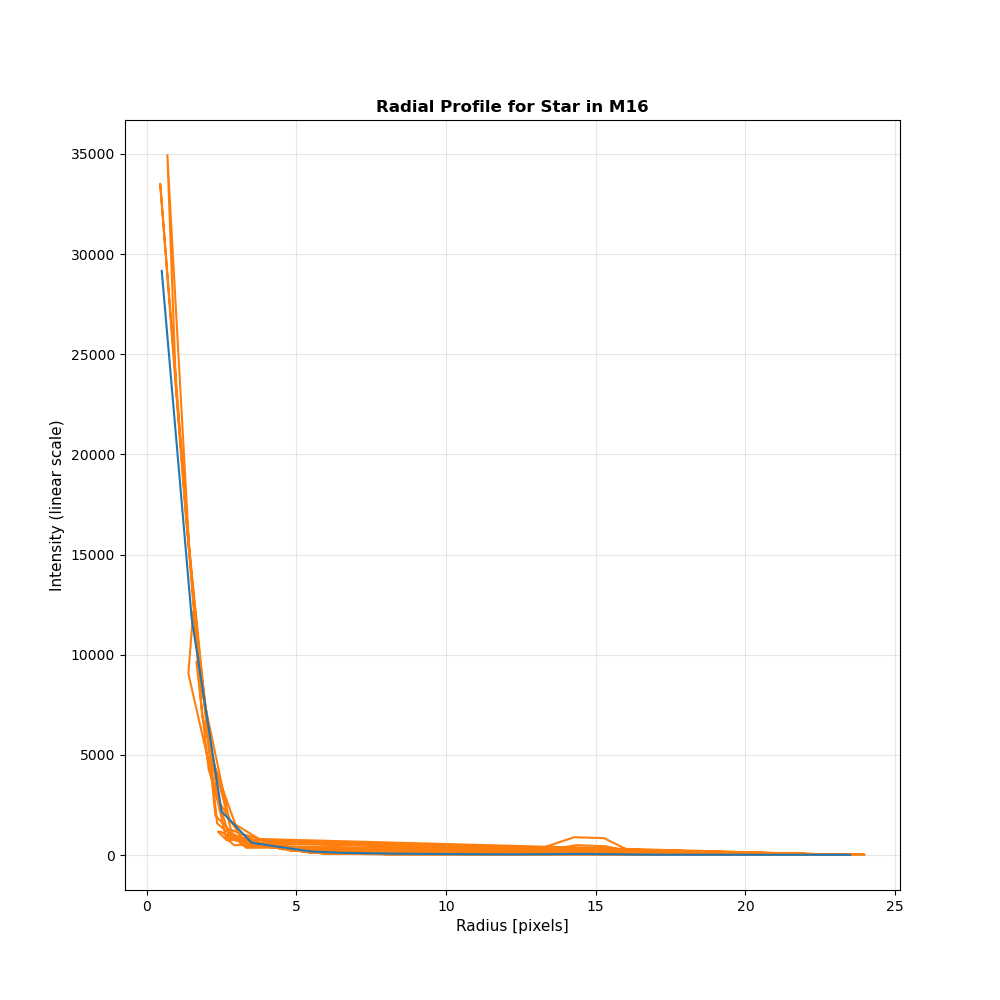

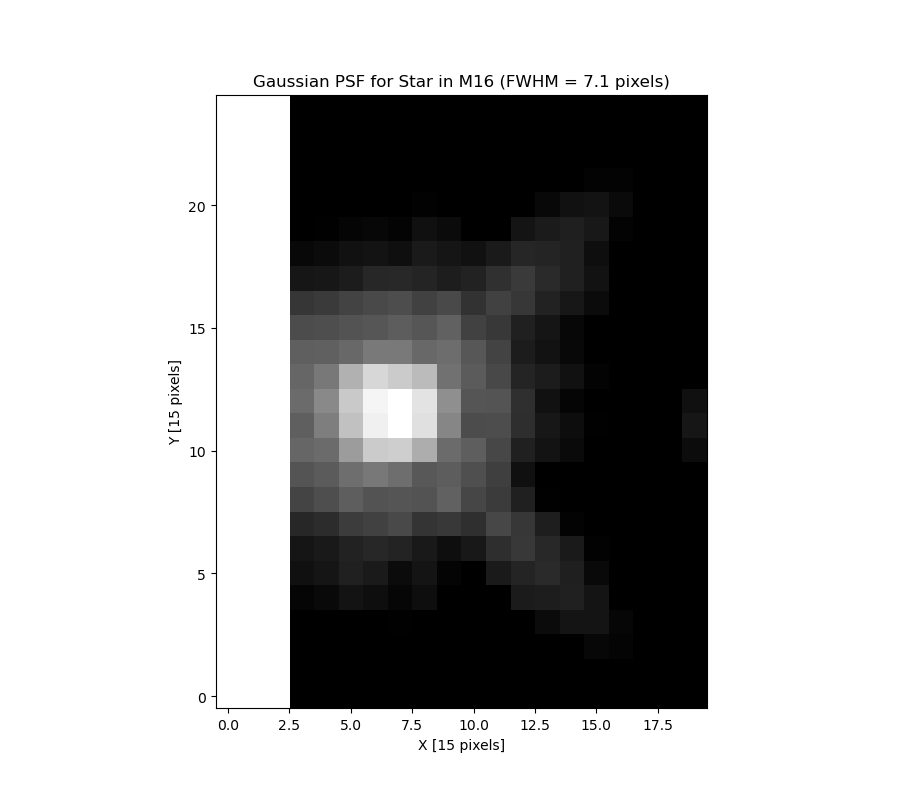

In [16]:
m16_cutout6 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
star6 = stars[5]
x_pos, y_pos, size, peak = star6['x_centroid'], star6['y_centroid'], star6['n_pixels'], star6['peak']
m16_cutout6.fit_star_psf(m16_data, x_pos, y_pos, size, peak)

### Star 7

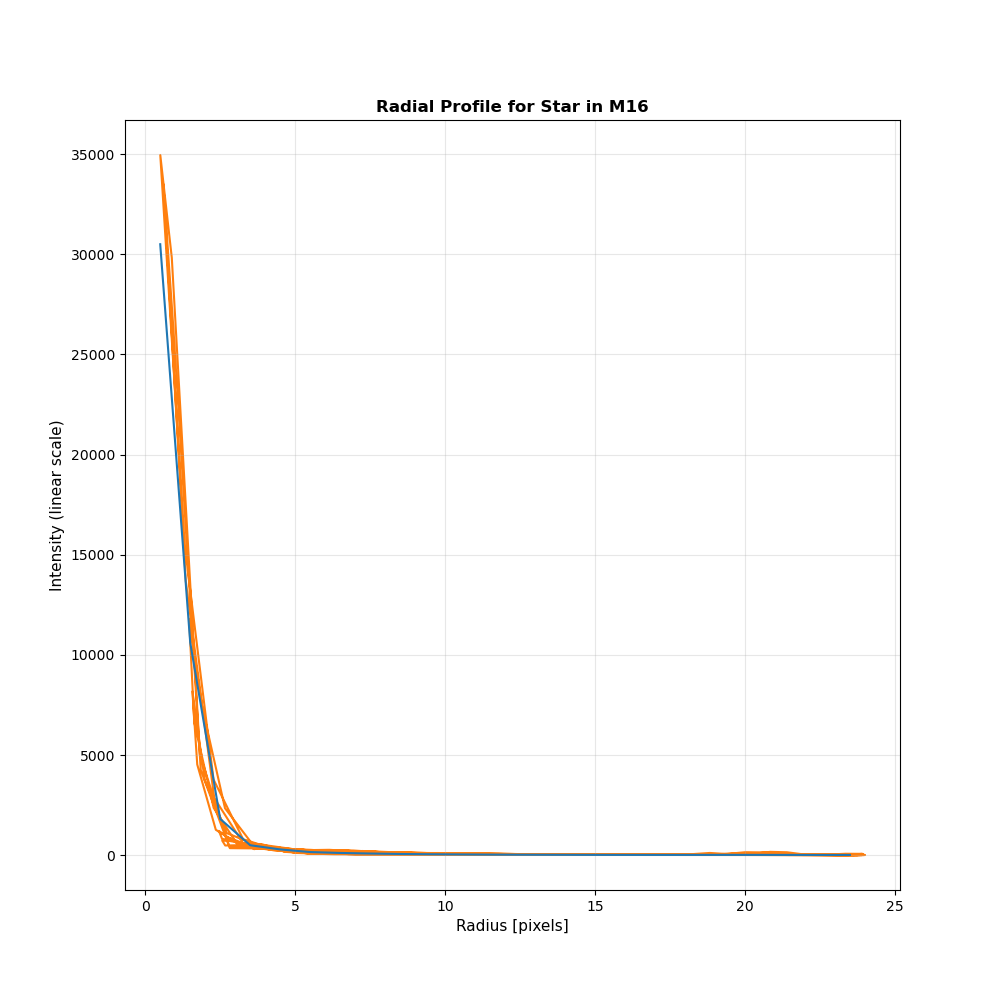

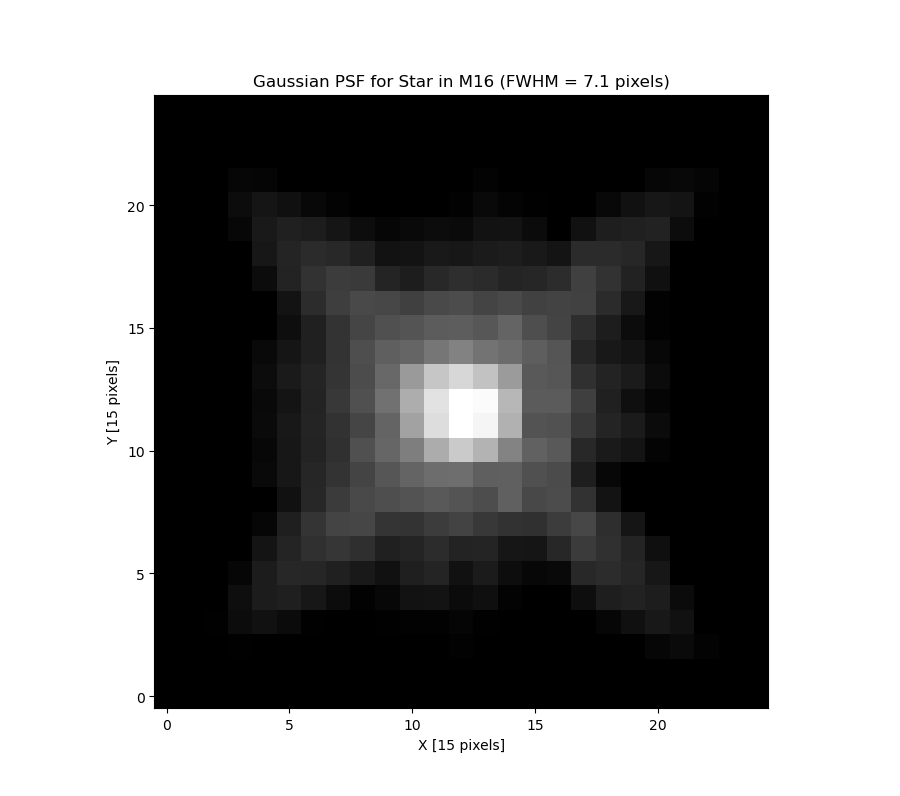

In [17]:
m16_cutout7 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
star7 = stars[6]
x_pos, y_pos, size, peak = star7['x_centroid'], star7['y_centroid'], star7['n_pixels'], star7['peak']
m16_cutout7.fit_star_psf(m16_data, x_pos, y_pos, size, peak)

### Star 8

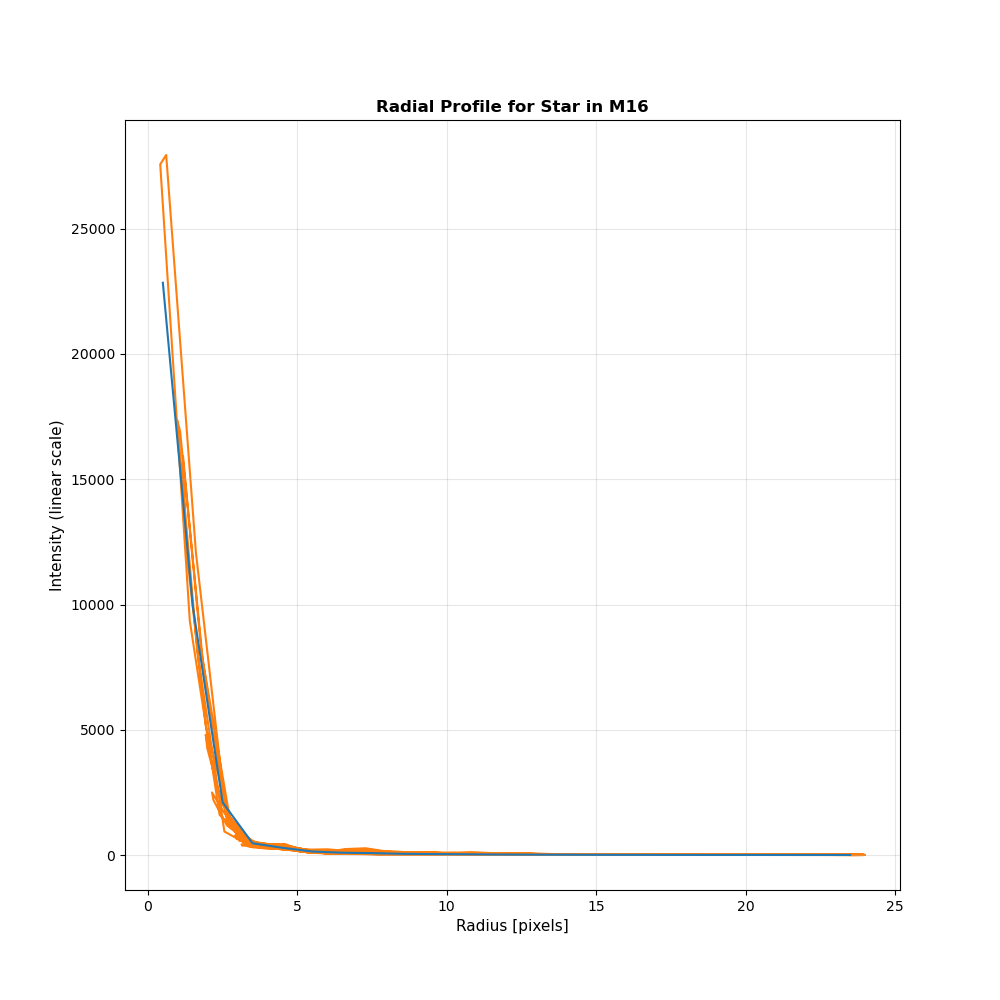

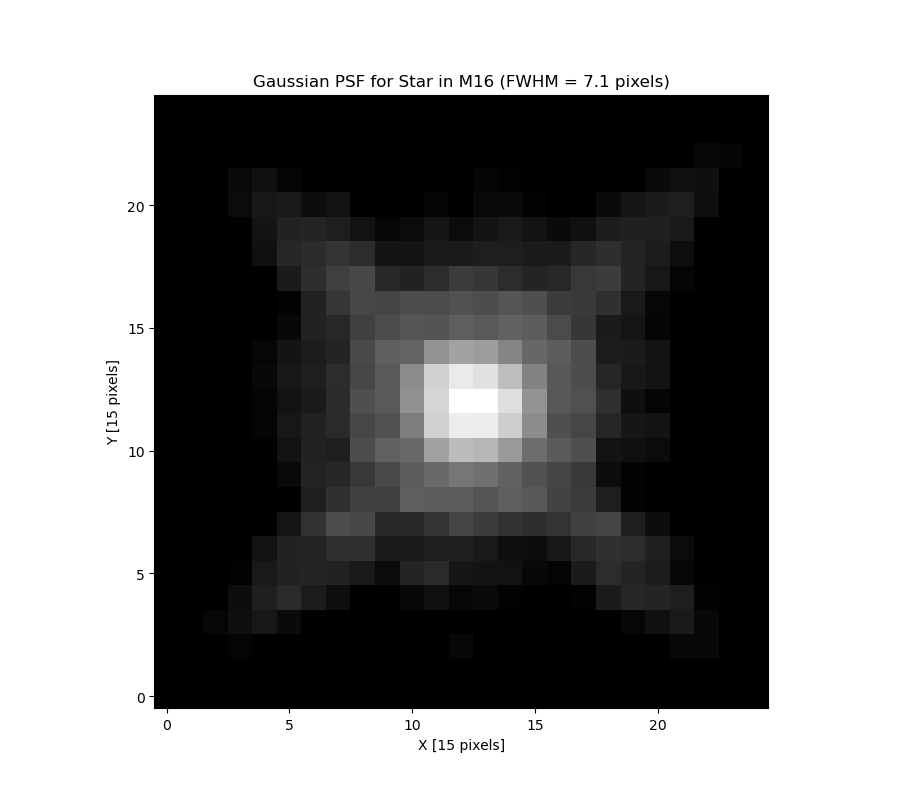

In [18]:
m16_cutout8 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
star8 = stars[7]
x_pos, y_pos, size, peak = star8['x_centroid'], star8['y_centroid'], star8['n_pixels'], star8['peak']
m16_cutout8.fit_star_psf(m16_data, x_pos, y_pos, size, peak)

### Star 9

C:\Users\mya\AppData\Local\Temp\ipykernel_13904\3451462309.py:84: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(fig_width, fig_height))


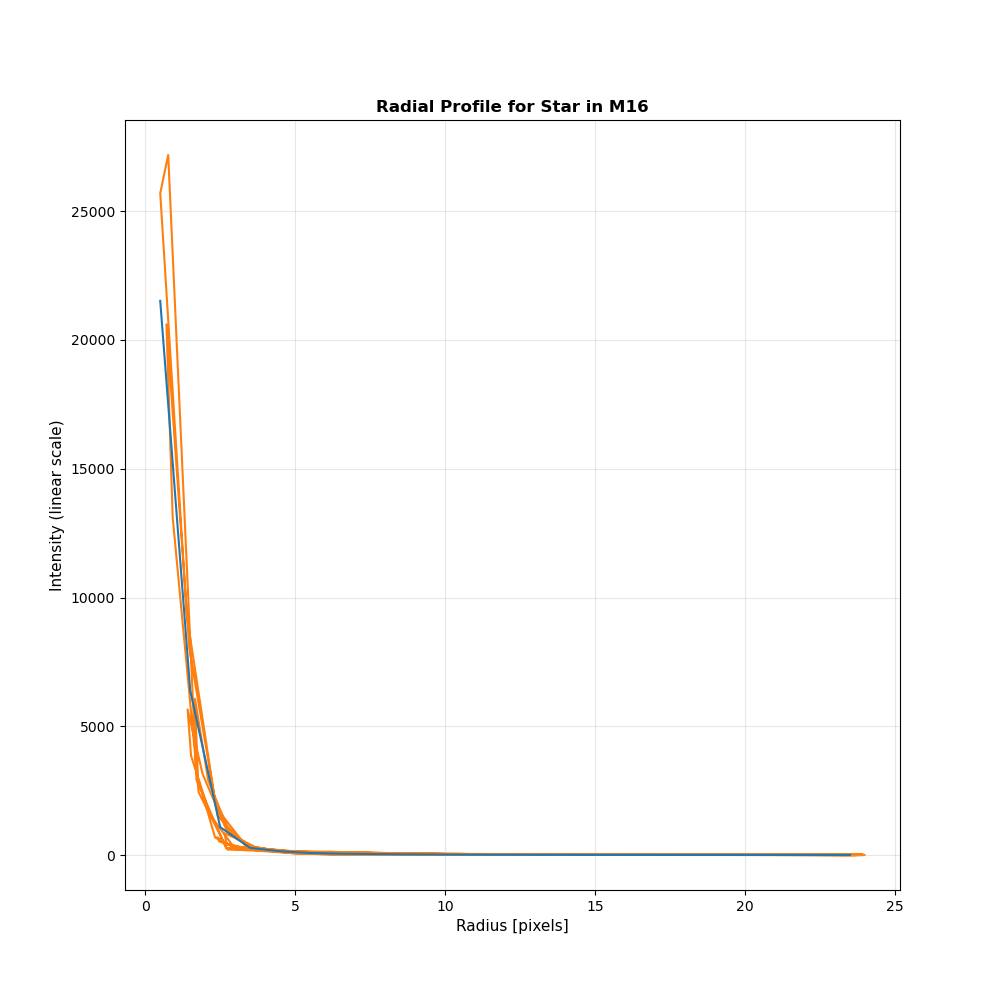

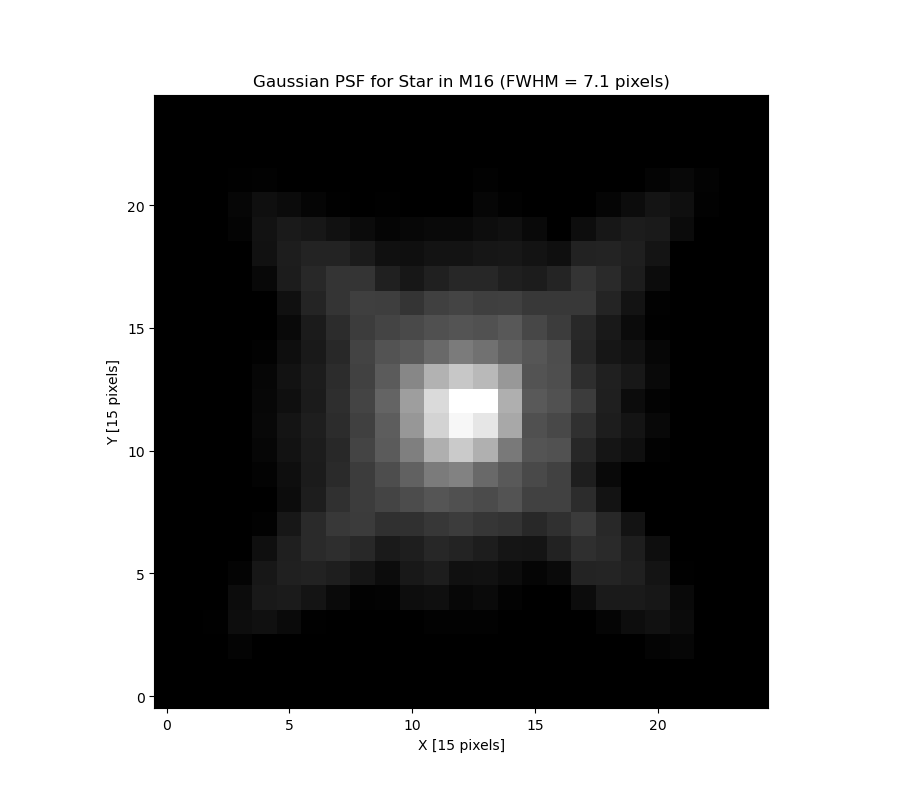

In [19]:
m16_cutout9 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
star9 = stars[8]
x_pos, y_pos, size, peak = star9['x_centroid'], star9['y_centroid'], star9['n_pixels'], star9['peak']
m16_cutout9.fit_star_psf(m16_data, x_pos, y_pos, size, peak)

### Star 10

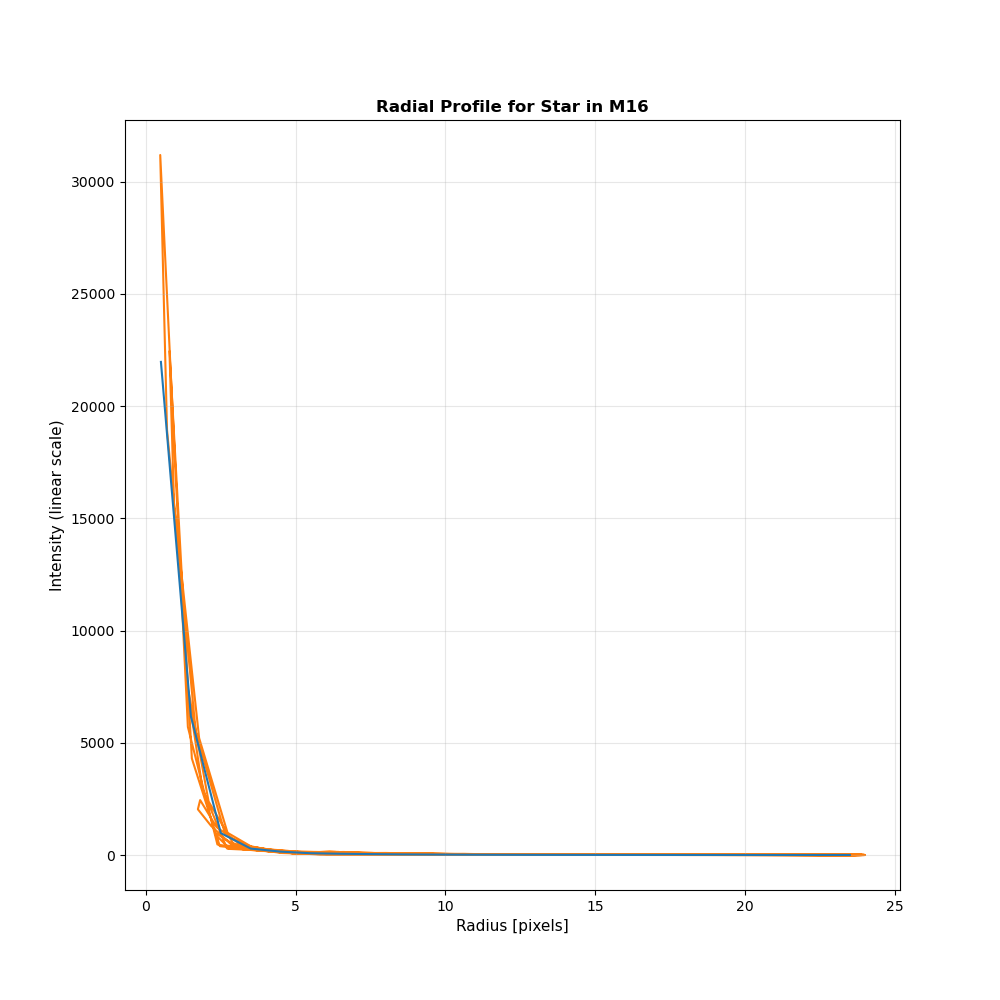

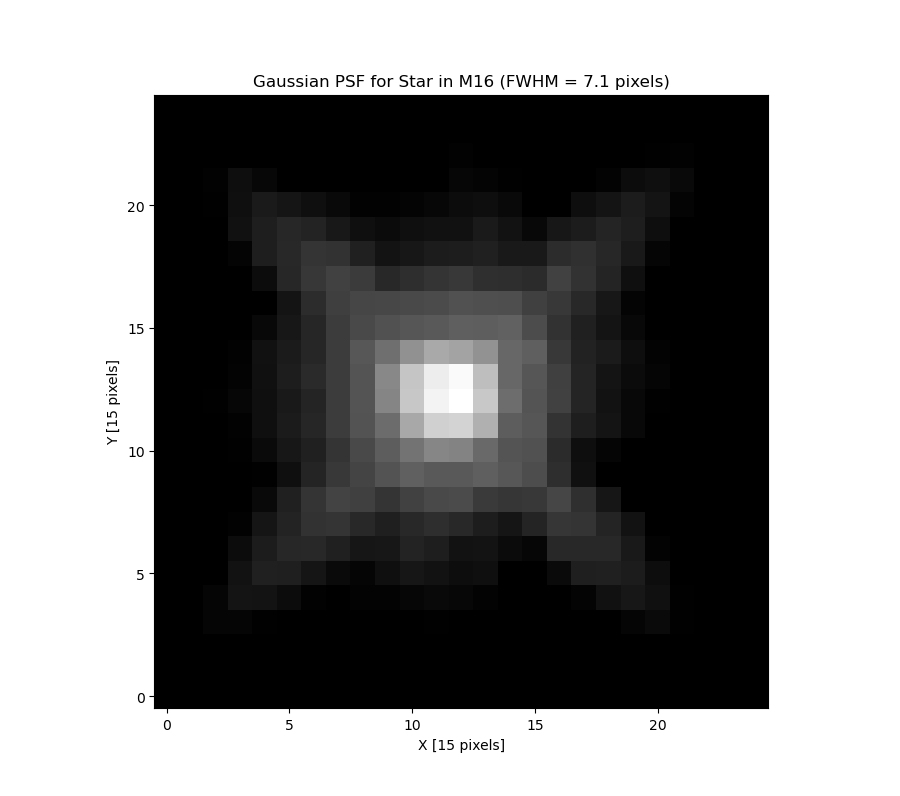

In [20]:
m16_cutout10 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
star10 = stars[9]
x_pos, y_pos, size, peak = star10['x_centroid'], star10['y_centroid'], star10['n_pixels'], star10['peak']
m16_cutout10.fit_star_psf(m16_data, x_pos, y_pos, size, peak)

## Section 4: Color Magnitude Diagram (CMD)
### Here, we use the data for the entire M16 star cluster to create CMD, which provides plots the magnitude (brightness) against the color of the star by a second filter for the data. In turn, the CMD provides information about a star's evolution, including brightness, temperature, and age.  

In [8]:
import numpy as np
import matplotlib.image as mpimg

from astroquery.mast import Observations
from astroquery.mast import Catalogs
import pandas as pd
import astropy.io.fits as fits

### Second filter for the CMD

In [21]:
m16_url2 = "https://mast.stsci.edu/api/v0.1/Download/file/?uri=mast:HST/product/idnm29yuq_drz.fits" #URL of M16 image from the MAST Archive 
m16_file2 = download_file(m16_url2, cache = True)
m16_file2 
#"https://opencomputinglab.github.io/SubjectMatterNotebooks/astronomy/fits-images.html"
m16_hdu_list2 = fits.open(m16_file2) 
if '2m16.fits' not in os.listdir():
    m16_hdu_list2.writeto('2m16.fits')
    print("File successfully downloaded!")
else:
    print("File is already downloaded.")

m16_data2 = fits.getdata('2m16.fits')

File is already downloaded.


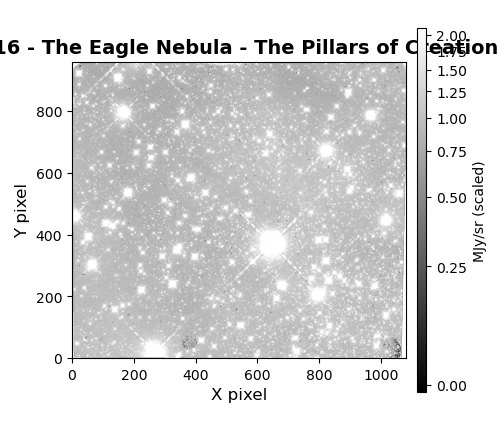

1.0200822 0.9827475 0.18045196


id,x_centroid,y_centroid,sharpness,roundness1,roundness2,n_pixels,peak,flux,mag,daofind_mag
int64,float64,float64,float64,float32,float64,int64,float32,float32,float32,float64
1,643.526510987632,368.5216174780226,0.37175457894449593,-0.254621,-0.1311514724395254,25,37537.92,442519.47,-14.11483,-11.24660193025212
2,267.81550903845545,17.45061243886058,0.5598720174925236,-0.04562018,0.17617839705226668,25,39287.184,282592.0,-13.6279,-11.39363580228003
3,167.29159040087976,792.9967275368809,0.7821012808847719,-0.15287736,-0.11920250905473558,25,24301.709,100211.2,-12.502291,-10.801928793631463
4,820.3449424321931,668.7864608738246,0.6935060250561241,-0.28446755,-0.11936744518782501,25,19167.846,91555.055,-12.404205,-10.609600647464493
5,791.0779712032976,202.17092150757728,0.9452148430651836,0.03429332,0.000984837966102812,25,27601.877,82467.19,-12.290703,-10.841144973413403
6,6.706345191842004,458.81733362018394,0.8979004616277496,0.05775415,-0.08582556235651718,25,19597.56,65758.305,-12.044877,-10.494608480256911
7,1013.4448835165105,443.24006002224826,0.6808118516872255,-0.40702948,-0.2048660817689887,25,9340.001,45920.863,-11.6550255,-9.838707779654287
8,964.5348250382822,782.5463146104339,0.5739426895874535,-0.64901954,-0.1640860693726603,25,7495.503,44661.633,-11.624837,-9.671716529334105
9,65.03262586972448,300.9045561846849,0.7998388706177552,-0.19300714,-0.19849928414175189,25,9582.124,36573.73,-11.407924,-9.79663160443699


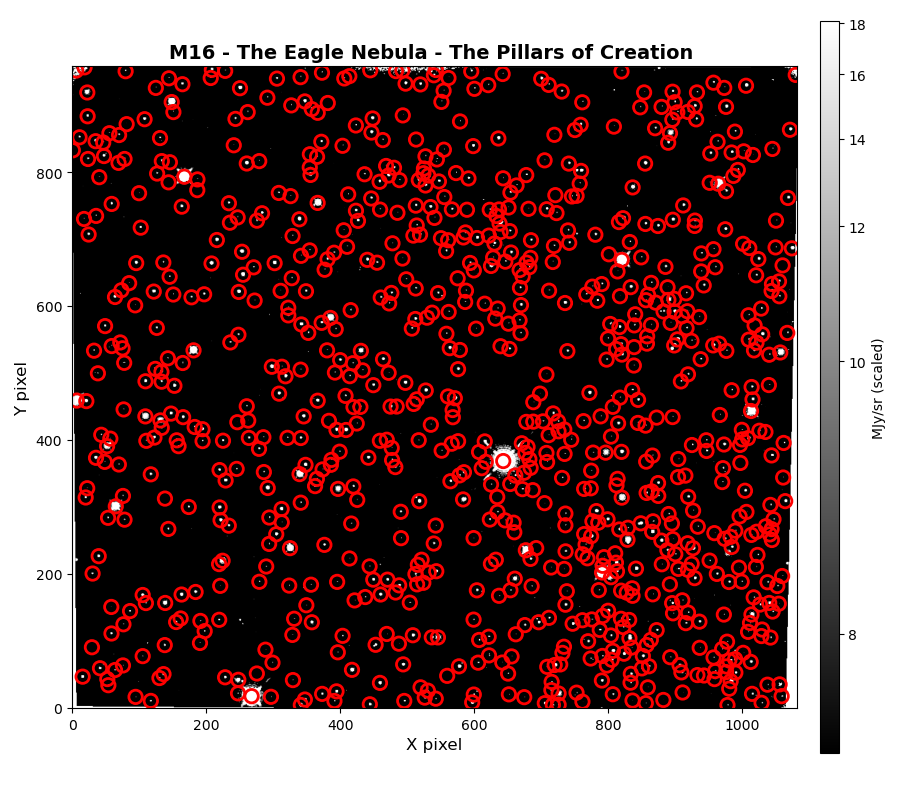

In [22]:
m16_2 = ClusterAnalyzer(m16_file2, m16_data2, m16_hdu_list2)
m16_2.show_image(m16_data2, m16_file2)
m16_2.detect_star(m16_data2)


1.0200822 0.9827475 0.18045196


id,x_centroid,y_centroid,sharpness,roundness1,roundness2,n_pixels,peak,flux,mag,daofind_mag
int64,float64,float64,float64,float32,float64,int64,float32,float32,float32,float64
1,643.526510987632,368.5216174780226,0.37175457894449593,-0.254621,-0.1311514724395254,25,37537.92,442519.47,-14.11483,-11.24660193025212
2,267.81550903845545,17.45061243886058,0.5598720174925236,-0.04562018,0.17617839705226668,25,39287.184,282592.0,-13.6279,-11.39363580228003
3,167.29159040087976,792.9967275368809,0.7821012808847719,-0.15287736,-0.11920250905473558,25,24301.709,100211.2,-12.502291,-10.801928793631463
4,820.3449424321931,668.7864608738246,0.6935060250561241,-0.28446755,-0.11936744518782501,25,19167.846,91555.055,-12.404205,-10.609600647464493
5,791.0779712032976,202.17092150757728,0.9452148430651836,0.03429332,0.000984837966102812,25,27601.877,82467.19,-12.290703,-10.841144973413403
6,6.706345191842004,458.81733362018394,0.8979004616277496,0.05775415,-0.08582556235651718,25,19597.56,65758.305,-12.044877,-10.494608480256911
7,1013.4448835165105,443.24006002224826,0.6808118516872255,-0.40702948,-0.2048660817689887,25,9340.001,45920.863,-11.6550255,-9.838707779654287
8,964.5348250382822,782.5463146104339,0.5739426895874535,-0.64901954,-0.1640860693726603,25,7495.503,44661.633,-11.624837,-9.671716529334105
9,65.03262586972448,300.9045561846849,0.7998388706177552,-0.19300714,-0.19849928414175189,25,9582.124,36573.73,-11.407924,-9.79663160443699


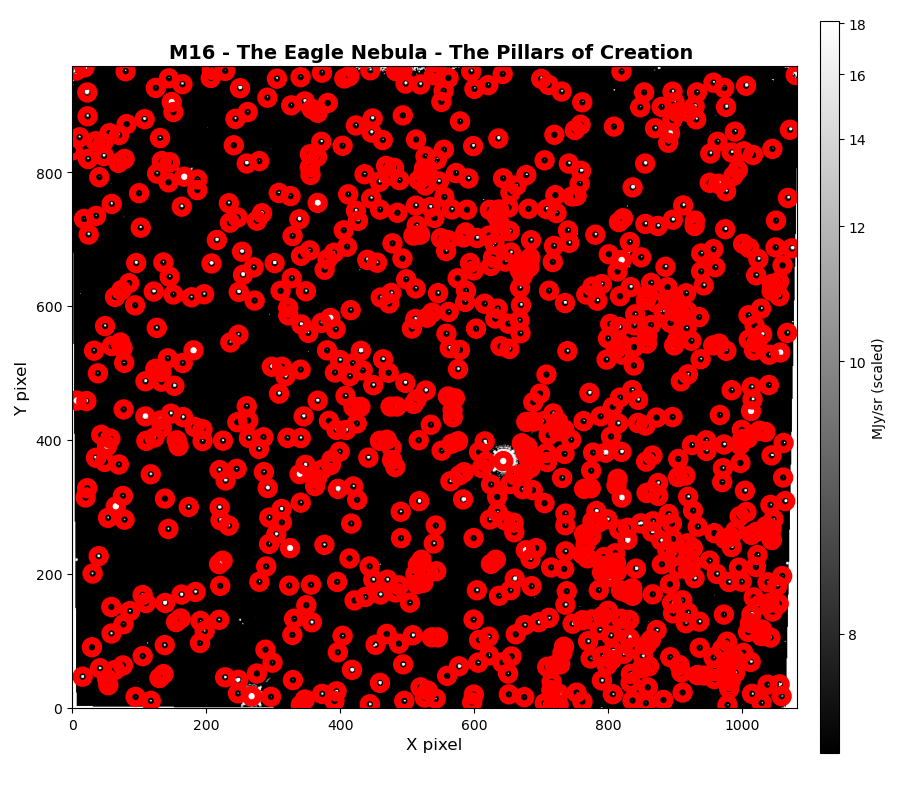

In [23]:

mean, median, std = sigma_clipped_stats(m16_data2, sigma=3.0) 
print(mean, median, std)

daofind = DAOStarFinder(fwhm=3.0, threshold=5*std, n_brightest=900) #locating stars from FITS data
# searches images for local density maxima that have a peak amplitude greater than threshold (approximately; threshold is applied to a convolved image) and have a size and shape similar to the defined 2D Gaussian kernel (eveything is already fit)
# find sources and display in a table

sources = daofind(m16_data2-median)
display(sources)
#bright_sources = sources[sources['flux'] > 5000]

#display(bright_sources)

 # code from DESI ASTRO, image display with circular apertures around each star from the x & y position data
positions = np.transpose((sources['x_centroid'],sources['y_centroid']))
plt.figure(figsize=(fig_width, fig_height)) 
apertures = CircularAperture(positions,r=10) 
apertures.plot(color='red',lw=5)

plt.imshow(m16_data2, cmap='gray', origin='lower', norm=norm)
plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
            fontsize=14, fontweight='bold')
plt.xlabel('X pixel', fontsize=12)
plt.ylabel('Y pixel', fontsize=12)
plt.tight_layout()
plt.show()

In [24]:
stars2 = sources['id', 'x_centroid', 'y_centroid', 'n_pixels', 'mag', 'peak']
display(stars)
display(stars2)

id,x_centroid,y_centroid,n_pixels,mag,peak
int64,float64,float64,int64,float32,float32
1,643.7391006747155,368.2685504324055,25,-14.590075,39936.85
2,267.9713283886196,17.58503719254132,25,-14.42507,43425.26
3,791.3415328060985,202.04279227949456,25,-13.947047,40200.176
4,820.4151048443399,668.5889452719462,25,-13.942236,36826.996
5,1013.7072451688485,443.02196240569515,25,-13.571416,37766.242
6,6.737797562616275,458.63544548266367,25,-13.416302,34938.93
7,65.23376750696886,300.55585965664204,25,-13.370023,34945.03
8,167.39788741409376,792.8931609692703,25,-13.225998,27924.668
9,181.3321270598217,533.6256775669736,25,-12.891302,25682.902


id,x_centroid,y_centroid,n_pixels,mag,peak
int64,float64,float64,int64,float32,float32
1,643.526510987632,368.5216174780226,25,-14.11483,37537.92
2,267.81550903845545,17.45061243886058,25,-13.6279,39287.184
3,167.29159040087976,792.9967275368809,25,-12.502291,24301.709
4,820.3449424321931,668.7864608738246,25,-12.404205,19167.846
5,791.0779712032976,202.17092150757728,25,-12.290703,27601.877
6,6.706345191842004,458.81733362018394,25,-12.044877,19597.56
7,1013.4448835165105,443.24006002224826,25,-11.6550255,9340.001
8,964.5348250382822,782.5463146104339,25,-11.624837,7495.503
9,65.03262586972448,300.9045561846849,25,-11.407924,9582.124


In [25]:
# Sending the PSFMAG data to a numpy array
magnitudes = abs(stars["mag"][0:500]), abs(stars2['mag'][0:500])
magnitudes = np.array(magnitudes)

# Creating arrays for g-band and r-band magnitudes
g_band = stars['mag']
r_band = stars2['mag']

# Calculating color (g - r)
#color_data1 = abs(g_band - r_band)
color_data1 = g_band - r_band
print(color_data1)

    mag    
-----------
-0.47524452
 -0.7971697
 -1.4447565
 -1.5380306
 -1.2807131
 -1.3714247
 -1.7149973
  -1.601161
 -1.4833784
 -1.7502689
        ...
 -1.2017598
 -1.2012043
 -1.2001054
 -1.1993647
 -1.2045317
 -1.2018809
 -1.2002659
 -1.1992006
 -1.1992767
 -1.1926367
Length = 900 rows


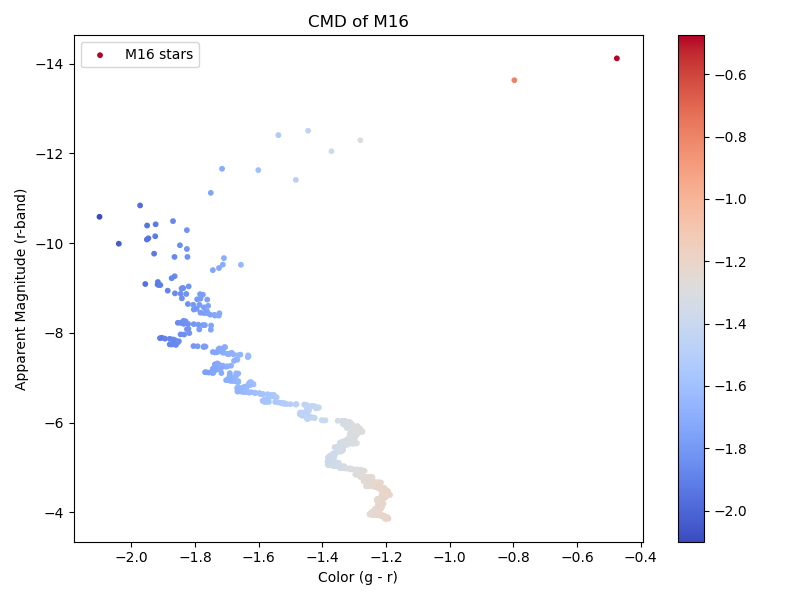

In [31]:
# Plotting the CMD
plt.figure(figsize=(8, 6))
plt.scatter(color_data1, r_band, s=10, c=color_data1, cmap='coolwarm', label="M16 stars")
#plt.ylim(10, 30)
plt.gca().invert_yaxis()
#plt.xlim(-2, 2)
plt.title("CMD of M16")
plt.ylabel("Apparent Magnitude (r-band)")
plt.xlabel("Color (g - r)")
plt.legend()
plt.colorbar()
#plt.grid(True)
plt.tight_layout()
plt.show()

#### The CMD indicates that top right stars are giants, the stars at the top left of main sequence are hot and bright, and the stars to the lower right of main sequence are cooler and less bright. Many of these stars are young, hence the large volume of bright stars and the minimal amount of giants.